Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')
Index(['loudness', 'speechiness', 'tempo', 'valence', 'acousticness'], dtype='object')
   loudness  speechiness    tempo  valence  acousticness  energy
0    -2.634       0.0583  122.036    0.518        0.1020   0.916
1    -4.969       0.0373   99.972    0.693        0.0724   0.815
2    -3.432       0.0742  124.008    0.613        0.0794   0.931
3    -3.778       0.1020  121.956    0.277        0.0287   0.930
4       NaN       0.0359  123.976    0.725        0.0803   0.833
Mean of energy: 0.6986192707032558
Standard deviation of energy: 0.18091003391959035


<ipython-input-4-6b0ebe1f6529>:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col_norm] = scaler.fit_transform(data[col_norm])
<ipython-input-4-6b0ebe1f6529>:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['energy'] = (data['energy'] > threshold).astype(int)


SVM Confusion Matrix:
[[3171 1306]
 [ 756 4617]]
SVM Accuracy: 0.7906598984771573
SVM Precision: 0.7795036299172716
SVM Recall: 0.8592964824120602
SVM F1 Score: 0.8174575070821529


<ipython-input-4-6b0ebe1f6529>:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=features, palette="viridis")


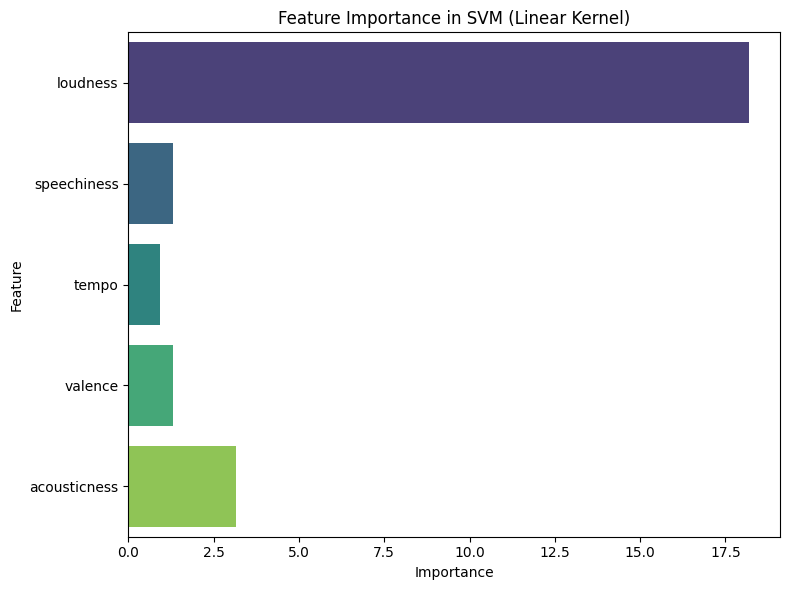

Naive Bayes Confusion Matrix:
[[2660 1817]
 [ 708 4665]]
Naive Bayes Accuracy: 0.7436548223350253
Naive Bayes Precision: 0.7196852823202715
Naive Bayes Recall: 0.8682300390843104
Naive Bayes F1 Score: 0.7870097005482919


<ipython-input-4-6b0ebe1f6529>:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance_nb, y=features, palette="coolwarm")


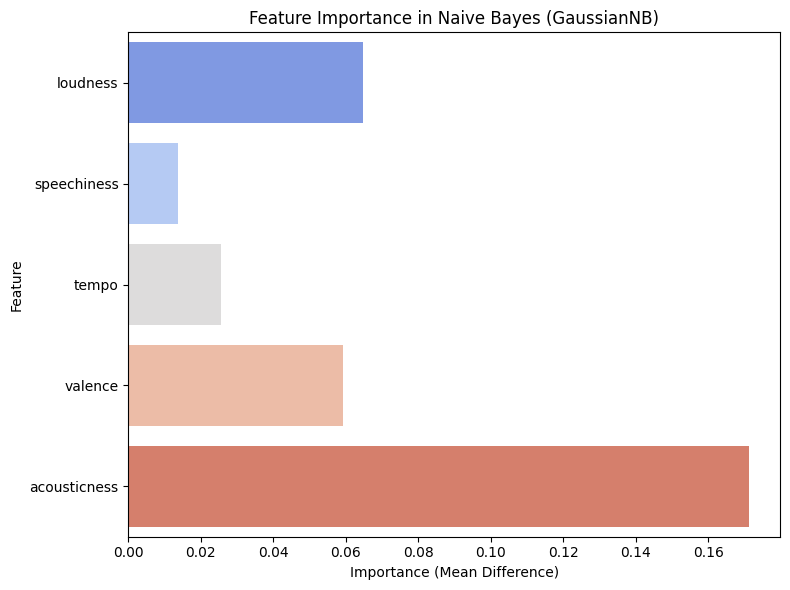

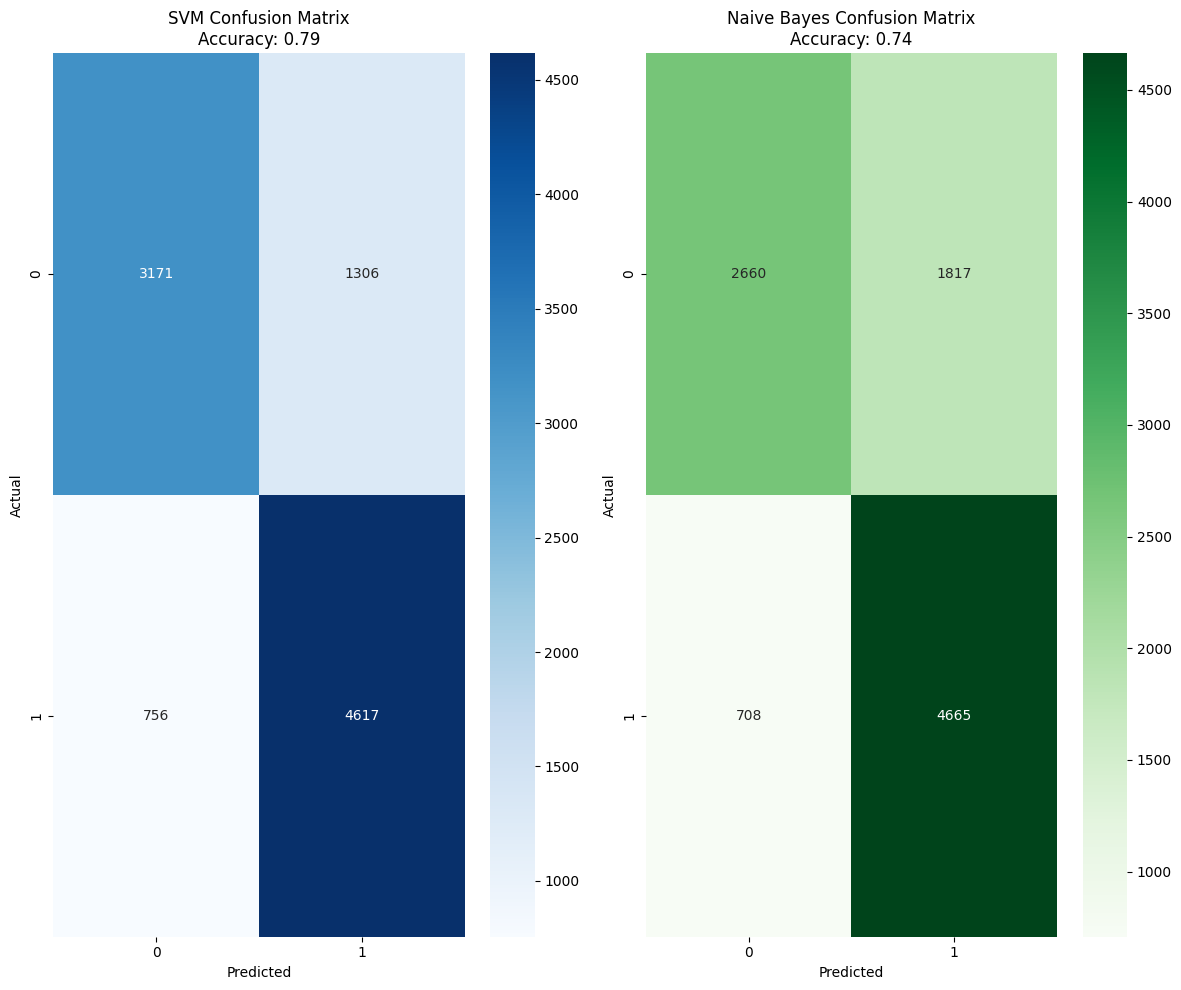

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

# Loading Dataset
songs = pd.read_csv("/spotify_songs.csv")

# Listing variables
print(songs.columns)

feat = songs[["loudness", "speechiness", "tempo", "valence", "acousticness"]]
target = songs["energy"]

# Listing Features
print(feat.columns)

data = songs[["loudness", "speechiness", "tempo", "valence", "acousticness", "energy"]]
print(data.head())
print(f"Mean of energy: {data['energy'].mean()}")
print(f"Standard deviation of energy: {data['energy'].std()}")

# Normalizing Data
col_norm = ["loudness", "speechiness", "tempo", "acousticness"]
scaler = MinMaxScaler()
data[col_norm] = scaler.fit_transform(data[col_norm])

threshold = 0.7
data['energy'] = (data['energy'] > threshold).astype(int)

imputer = SimpleImputer(strategy='mean') # You can choose other strategies like 'median' or 'most_frequent'

# Splitting data into train & test
X = data.drop('energy', axis=1)
y = data['energy']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

# Fit and transform on your training data
X_train = imputer.fit_transform(X_train)

# Only transform your test data
X_test = imputer.transform(X_test)

# 1. Support Vector Machine
svm_model = SVC()
svm_model.fit(X_train, y_train)

# Making predictions
svm_predictions = svm_model.predict(X_test)

# Confusion Matrix
svm_conf_matrix = confusion_matrix(y_test, svm_predictions)
print("SVM Confusion Matrix:")
print(svm_conf_matrix)

# Metrics
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)

print(f"SVM Accuracy: {svm_accuracy}")
print(f"SVM Precision: {svm_precision}")
print(f"SVM Recall: {svm_recall}")
print(f"SVM F1 Score: {svm_f1}")

# Ensure the SVM model uses a linear kernel for feature importance
svm_model_linear = SVC(kernel='linear')
svm_model_linear.fit(X_train, y_train)

# Extracting feature importance (coefficients of the linear SVM model)
feature_importance = np.abs(svm_model_linear.coef_[0])

# Plotting the feature importance
features = X.columns
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance, y=features, palette="viridis")
plt.title("Feature Importance in SVM (Linear Kernel)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# 2. Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

# Make predictions
nb_predictions = nb_model.predict(X_test)

# Confusion Matrix
nb_conf_matrix = confusion_matrix(y_test, nb_predictions)
print("Naive Bayes Confusion Matrix:")
print(nb_conf_matrix)

# Metrics
nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions)
nb_recall = recall_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions)

print(f"Naive Bayes Accuracy: {nb_accuracy}")
print(f"Naive Bayes Precision: {nb_precision}")
print(f"Naive Bayes Recall: {nb_recall}")
print(f"Naive Bayes F1 Score: {nb_f1}")

# Calculate feature importance for Gaussian Naive Bayes
# Use the absolute value of the mean difference between the classes as a proxy for feature importance
class_means = nb_model.theta_  # Mean of each feature per class
feature_importance_nb = np.abs(class_means[0] - class_means[1])

# Plotting the feature importance
features = X.columns
plt.figure(figsize=(8, 6))
sns.barplot(x=feature_importance_nb, y=features, palette="coolwarm")
plt.title("Feature Importance in Naive Bayes (GaussianNB)")
plt.xlabel("Importance (Mean Difference)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Plot Confusion Matrices
plt.figure(figsize=(12, 10))

# SVM Confusion Matrix
plt.subplot(1, 2, 1)
sns.heatmap(svm_conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f"SVM Confusion Matrix\nAccuracy: {svm_accuracy:.2f}")
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Naive Bayes Confusion Matrix
plt.subplot(1, 2, 2)
sns.heatmap(nb_conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.title(f"Naive Bayes Confusion Matrix\nAccuracy: {nb_accuracy:.2f}")
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()
